In [1]:
import pandas as pd


In [2]:
df = pd.read_csv(r"C:\Users\adity\Downloads\OnlineRetail.csv", encoding="latin1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,$2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,$3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,$2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,$3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,$3.39,17850.0,United Kingdom


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  object 
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()
#NULL VALUES SPCIFICALLY

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
missing = df.isnull().sum()

missing_percentage = (missing / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})

missing_summary

,Missing Values,Percentage
InvoiceNo,0,0.000000
StockCode,0,0.000000
Description,1454,0.268311
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
CustomerID,135080,24.926694
Country,0,0.000000


In [7]:
df[df["Description"].isnull()].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,01-12-2010 11:52,$-,NaN,United Kingdom
1970,536545,21134,NaN,1,01-12-2010 14:32,$-,NaN,United Kingdom
1971,536546,22145,NaN,1,01-12-2010 14:33,$-,NaN,United Kingdom
1972,536547,37509,NaN,1,01-12-2010 14:33,$-,NaN,United Kingdom
1987,536549,85226A,NaN,1,01-12-2010 14:34,$-,NaN,United Kingdom
1988,536550,85044,NaN,1,01-12-2010 14:34,$-,NaN,United Kingdom
2024,536552,20950,NaN,1,01-12-2010 14:34,$-,NaN,United Kingdom
2025,536553,37461,NaN,3,01-12-2010 14:35,$-,NaN,United Kingdom
2026,536554,84670,NaN,23,01-12-2010 14:35,$-,NaN,United Kingdom
2406,536589,21777,NaN,-10,01-12-2010 16:50,$-,NaN,United Kingdom


In [8]:
df[df["Description"].isnull()]["Quantity"].value_counts()

Quantity
 1       126
-1        73
 2        66
-2        52
-5        40
        ... 
-64        1
 192       1
 5568      1
-620       1
-144       1
Name: count, Length: 266, dtype: int64

In [9]:
df[df["Description"].isnull()]["UnitPrice"].value_counts()

UnitPrice
$-       1454
Name: count, dtype: int64

In [10]:
df["UnitPrice"].head(20)

0      $2.55 
1      $3.39 
2      $2.75 
3      $3.39 
4      $3.39 
5      $7.65 
6      $4.25 
7      $1.85 
8      $1.85 
9      $1.69 
10     $2.10 
11     $2.10 
12     $3.75 
13     $1.65 
14     $4.25 
15     $4.95 
16     $9.95 
17     $5.95 
18     $5.95 
19     $7.95 
Name: UnitPrice, dtype: object

In [11]:
df["UnitPrice"].dtype

dtype('O')

In [12]:
df["UnitPrice"].unique()[:20]

array([' $2.55 ', ' $3.39 ', ' $2.75 ', ' $7.65 ', ' $4.25 ', ' $1.85 ',
       ' $1.69 ', ' $2.10 ', ' $3.75 ', ' $1.65 ', ' $4.95 ', ' $9.95 ',
       ' $5.95 ', ' $7.95 ', ' $0.85 ', ' $0.65 ', ' $1.25 ', ' $2.95 ',
       ' $1.95 ', ' $0.42 '], dtype=object)

In [13]:
df["UnitPrice"] = (
    df["UnitPrice"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
    .replace("-", "0")
    .astype(float)
)

In [14]:
df["UnitPrice"].dtype

dtype('float64')

In [15]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [16]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    dayfirst=True
)

In [17]:
df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [18]:
df.duplicated().sum()

np.int64(5268)

In [19]:
df[df.duplicated(keep=False)].sort_values(
    by=["InvoiceNo", "StockCode"]
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [20]:
s=df.drop_duplicates()
# TO DROP EXACT DUPLICATES OR SAME RECORDS

In [21]:
s.shape

(536641, 8)

In [22]:
df[df["Quantity"] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [23]:
negative_quantity = df[df["Quantity"] < 0]

negative_quantity.shape

(10624, 8)

In [24]:
negative_quantity["InvoiceNo"].str.startswith("C").value_counts()

InvoiceNo
True     9288
False    1336
Name: count, dtype: int64

In [25]:
# Show transactions where StockCode contains letters
letter_codes = df[
    df["StockCode"].astype(str).str.contains(
        r"[A-Za-z]", regex=True
    )
]

letter_codes[[
    "StockCode",
    "Description",
    "Quantity",
    "UnitPrice"
]].drop_duplicates().head(50)

,StockCode,Description,Quantity,UnitPrice
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55
2,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39
4,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39
45,POST,POSTAGE,3,18.00
60,82494L,WOODEN FRAME ANTIQUE WHITE,6,2.55
87,85099C,JUMBO BAG BAROQUE BLACK WHITE,10,1.95
90,84997B,RED 3 PIECE RETROSPOT CUTLERY SET,12,3.75
91,84997C,BLUE 3 PIECE POLKADOT CUTLERY SET,6,3.75
100,84519A,TOMATO CHARLIE+LOLA COASTER SET,6,2.95


In [26]:
df[df["StockCode"].isin(["POST", "D"])][
    ["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
45,536370,POST,POSTAGE,3,18.00
141,C536379,D,Discount,-1,27.50
386,536403,POST,POSTAGE,1,15.00
1123,536527,POST,POSTAGE,1,18.00
5073,536840,POST,POSTAGE,1,18.00
5258,536852,POST,POSTAGE,1,18.00
5325,536858,POST,POSTAGE,2,40.00
5369,536861,POST,POSTAGE,3,18.00
6602,536967,POST,POSTAGE,1,18.00
6676,536974,POST,POSTAGE,2,18.00


In [27]:
letter_only_codes = df[
    df["StockCode"].astype(str).str.fullmatch(r"[A-Za-z]+")
]

letter_only_codes["StockCode"].value_counts()

StockCode
POST         1256
DOT           710
M             571
D              77
S              63
AMAZONFEE      34
CRUK           16
DCGSSGIRL      13
DCGSSBOY       11
PADS            4
B               3
m               1
Name: count, dtype: int64

In [28]:
special_codes = [
    "POST", "DOT", "M", "m", "D", "S",
    "AMAZONFEE", "CRUK", "DCGSSGIRL",
    "DCGSSBOY", "PADS", "B"
]

special_transactions = df[
    df["StockCode"].isin(special_codes)
]

special_transactions[
    [
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice"
    ]
].drop_duplicates().sort_values("StockCode")

,StockCode,Description,Quantity,UnitPrice
191385,AMAZONFEE,AMAZON FEE,-1,5876.40
312246,AMAZONFEE,AMAZON FEE,-1,6662.51
446533,AMAZONFEE,AMAZON FEE,-1,8286.22
524602,AMAZONFEE,AMAZON FEE,-1,17836.46
524601,AMAZONFEE,AMAZON FEE,-1,11586.50
...,...,...,...,...
313422,S,SAMPLES,-1,239.07
14437,S,SAMPLES,-1,52.00
96710,S,SAMPLES,-1,37.49
419666,S,SAMPLES,1,33.05


In [29]:
excluded_codes = [
    "POST",
    "DOT",
    "M",
    "m",
    "D",
    "S",
    "AMAZONFEE",
    "CRUK",
    "DCGSSGIRL",
    "DCGSSBOY",
    "PADS",
    "B"
]

product_sales_df = df[
    ~df["StockCode"].isin(excluded_codes)
].copy()

In [30]:
product_sales_df.shape

(539150, 8)

In [31]:
negative_quantity = product_sales_df[
    product_sales_df["Quantity"] < 0
]

negative_quantity.shape

(10067, 8)

In [32]:
negative_quantity[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "CustomerID"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65,15311.0
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65,17548.0
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29,17548.0
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29,17548.0
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29,17548.0
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,3.45,17548.0
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65,17548.0
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,1.65,17548.0
939,C536506,22960,JAM MAKING SET WITH JARS,-6,4.25,17897.0
1441,C536543,22632,HAND WARMER RED RETROSPOT,-1,2.10,17841.0


In [33]:
negative_quantity["InvoiceNo"].astype(str).str.startswith("C").value_counts()

InvoiceNo
True     8731
False    1336
Name: count, dtype: int64

In [34]:
negative_quantity[
    ~negative_quantity["InvoiceNo"].astype(str).str.startswith("C")
][
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice
2406,536589,21777,NaN,-10,0.0
4347,536764,84952C,NaN,-38,0.0
7188,536996,22712,NaN,-20,0.0
7189,536997,22028,NaN,-20,0.0
7190,536998,85067,NaN,-6,0.0
7192,537000,21414,NaN,-22,0.0
7193,537001,21653,NaN,-6,0.0
7195,537003,85126,NaN,-2,0.0
7196,537004,21814,NaN,-30,0.0
7197,537005,21692,NaN,-70,0.0


In [35]:
returns_df = product_sales_df[
    product_sales_df["Quantity"] < 0
].copy()

In [36]:
returns_df.shape

(10067, 8)

In [37]:
sales_df = product_sales_df[
    product_sales_df["Quantity"] > 0
].copy()

In [38]:
sales_df.shape

(529083, 8)

In [39]:
print("Original product dataset:", product_sales_df.shape)
print("Sales dataset:", sales_df.shape)
print("Returns dataset:", returns_df.shape)

Original product dataset: (539150, 8)
Sales dataset: (529083, 8)
Returns dataset: (10067, 8)


In [40]:
sales_df["Revenue"] = (
    sales_df["Quantity"] * sales_df["UnitPrice"]
)

In [41]:
returns_df["Revenue"] = (
    returns_df["Quantity"] * returns_df["UnitPrice"]
)

In [42]:
sales_df[
    ["Quantity", "UnitPrice", "Revenue"]
].head(10)

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


In [43]:
sales_df[sales_df["UnitPrice"] <= 0].shape

(1166, 9)

In [44]:
sales_df["UnitPrice"].describe()

count    529083.000000
mean          3.271957
std           4.446968
min           0.000000
25%           1.250000
50%           2.080000
75%           4.130000
max         649.500000
Name: UnitPrice, dtype: float64

In [45]:
sales_df["Revenue"].describe()

count    529083.000000
mean         19.428029
std         268.271196
min           0.000000
25%           3.750000
50%           9.900000
75%          17.400000
max      168469.600000
Name: Revenue, dtype: float64

In [46]:
zero_price_sales = sales_df[
    sales_df["UnitPrice"] <= 0
]

zero_price_sales[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Revenue"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue
622,536414,22139,NaN,56,0.0,0.0
1970,536545,21134,NaN,1,0.0,0.0
1971,536546,22145,NaN,1,0.0,0.0
1972,536547,37509,NaN,1,0.0,0.0
1987,536549,85226A,NaN,1,0.0,0.0
1988,536550,85044,NaN,1,0.0,0.0
2024,536552,20950,NaN,1,0.0,0.0
2025,536553,37461,NaN,3,0.0,0.0
2026,536554,84670,NaN,23,0.0,0.0
4348,536765,84952C,NaN,19,0.0,0.0


In [47]:
zero_price_sales["Description"].value_counts().head(20)

Description
check                              39
found                              25
adjustment                         14
FRENCH BLUE METAL DOOR SIGN 1       9
Found                               8
FRENCH BLUE METAL DOOR SIGN 8       8
amazon                              8
OWL DOORSTOP                        7
FRENCH BLUE METAL DOOR SIGN 3       7
RECIPE BOX PANTRY YELLOW DESIGN     7
FRENCH BLUE METAL DOOR SIGN 4       7
FRENCH BLUE METAL DOOR SIGN No      7
Amazon                              7
?                                   6
FRENCH BLUE METAL DOOR SIGN 7       6
MINT KITCHEN SCALES                 6
FRENCH BLUE METAL DOOR SIGN 9       6
RED KITCHEN SCALES                  6
FRENCH BLUE METAL DOOR SIGN 5       6
FRENCH BLUE METAL DOOR SIGN 6       6
Name: count, dtype: int64

In [48]:
zero_price_sales[
    ["StockCode", "Description", "Quantity", "UnitPrice"]
].drop_duplicates().sort_values("Description").head(50)

,StockCode,Description,Quantity,UnitPrice
279324,22167,OVAL WALL MIRROR DIAMANTE,1,0.0
314747,22955,36 FOIL STAR CAKE CASES,144,0.0
14369,22620,4 TRADITIONAL SPINNING TOPS,1,0.0
220843,85123A,?,4000,0.0
282882,22171,?,142,0.0
115807,84988,?,3000,0.0
323315,23135,?,101,0.0
421093,72803A,?,117,0.0
38261,21479,?,752,0.0
33576,22580,ADVENT CALENDAR GINGHAM SACK,4,0.0


In [49]:
zero_price_sales[
    ["StockCode", "Description", "Quantity", "UnitPrice"]
].drop_duplicates().sort_values("Description").head(50)

,StockCode,Description,Quantity,UnitPrice
279324,22167,OVAL WALL MIRROR DIAMANTE,1,0.0
314747,22955,36 FOIL STAR CAKE CASES,144,0.0
14369,22620,4 TRADITIONAL SPINNING TOPS,1,0.0
220843,85123A,?,4000,0.0
282882,22171,?,142,0.0
115807,84988,?,3000,0.0
323315,23135,?,101,0.0
421093,72803A,?,117,0.0
38261,21479,?,752,0.0
33576,22580,ADVENT CALENDAR GINGHAM SACK,4,0.0


In [50]:
zero_price_sales["Quantity"].describe()

count     1166.000000
mean        58.529160
std        452.838141
min          1.000000
25%          1.000000
50%          3.000000
75%         20.000000
max      12540.000000
Name: Quantity, dtype: float64

In [51]:
zero_price_df = sales_df[
    sales_df["UnitPrice"] <= 0
].copy()

In [52]:
sales_clean_df = sales_df[
    sales_df["UnitPrice"] > 0
].copy()

In [53]:
print("Sales dataset:", sales_df.shape)
print("Zero-price transactions:", zero_price_df.shape)
print("Clean sales dataset:", sales_clean_df.shape)

Sales dataset: (529083, 9)
Zero-price transactions: (1166, 9)
Clean sales dataset: (527917, 9)


In [54]:
missing_customer = sales_clean_df[
    sales_clean_df["CustomerID"].isna()
].copy()

missing_customer.shape

(131436, 9)

In [55]:
missing_customer[
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Revenue"
    ]
].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2.51,2.51
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2.51,5.02
1445,536544,21786,POLKADOT RAIN HAT,4,0.85,3.40
1446,536544,21787,RAIN PONCHO RETROSPOT,2,1.66,3.32
1447,536544,21790,VINTAGE SNAP CARDS,9,1.66,14.94
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2.51,5.02
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,0.43,4.30
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,0.43,3.87
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,0.43,4.73
1452,536544,21809,CHRISTMAS HANGING TREE WITH BELL,1,2.51,2.51


In [56]:
missing_customer["Revenue"].sum()

np.float64(1511122.2399999998)

In [57]:
sales_clean_df.shape

(527917, 9)

In [58]:
customer_sales = sales_clean_df.dropna(
    subset=["CustomerID"]
).copy()

In [59]:
missing_description = sales_clean_df[
    sales_clean_df["Description"].isna()
].copy()

missing_description.shape

(0, 9)

In [60]:
missing_description[
    [
        "InvoiceNo",
        "StockCode",
        "Quantity",
        "UnitPrice",
        "Revenue"
    ]
].head(20)

,InvoiceNo,StockCode,Quantity,UnitPrice,Revenue


In [61]:
missing_customer = sales_clean_df[sales_clean_df['CustomerID'].isna()].copy()

In [62]:
missing_customer.shape

(131436, 9)

In [63]:
missing_customer[['InvoiceNo', 'StockCode', 'Description',
                  'Quantity', 'UnitPrice', 'Revenue']].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2.51,2.51
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2.51,5.02
1445,536544,21786,POLKADOT RAIN HAT,4,0.85,3.40
1446,536544,21787,RAIN PONCHO RETROSPOT,2,1.66,3.32
1447,536544,21790,VINTAGE SNAP CARDS,9,1.66,14.94
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2.51,5.02
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,0.43,4.30
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,0.43,3.87
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,0.43,4.73
1452,536544,21809,CHRISTMAS HANGING TREE WITH BELL,1,2.51,2.51


In [64]:
sales_clean_df['Revenue'].sum()

np.float64(10279039.89)

In [65]:
s.shape

(536641, 8)

In [66]:
sales_clean_df[['Quantity', 'UnitPrice', 'Revenue']].describe()

,Quantity,UnitPrice,Revenue
count,527917.000000,527917.000000,527917.000000
mean,10.564524,3.279184,19.470939
std,155.811039,4.449214,268.565740
min,1.000000,0.040000,0.060000
25%,1.000000,1.250000,3.750000
50%,3.000000,2.080000,9.900000
75%,11.000000,4.130000,17.460000
max,80995.000000,649.500000,168469.600000


In [67]:
print("Quantity <= 0:", (sales_clean_df['Quantity'] <= 0).sum())
print("UnitPrice <= 0:", (sales_clean_df['UnitPrice'] <= 0).sum())
print("Revenue <= 0:", (sales_clean_df['Revenue'] <= 0).sum())

Quantity <= 0: 0
UnitPrice <= 0: 0
Revenue <= 0: 0


In [68]:
sales_clean_df['StockCode'].value_counts().head(30)

StockCode
85123A    2265
85099B    2112
22423     2017
47566     1706
20725     1595
84879     1489
22197     1426
22720     1399
21212     1370
20727     1328
22383     1326
22457     1263
23203     1249
22386     1238
22469     1226
22086     1200
21931     1197
22411     1190
22382     1179
20728     1174
22961     1169
23298     1165
22960     1141
22666     1126
23209     1123
22384     1117
82482     1111
22993     1102
22699     1083
22727     1074
Name: count, dtype: int64

In [69]:
sales_clean_df['StockCode'].value_counts().tail(30)

StockCode
84968f      1
82615       1
84661b      1
21839       1
84743C      1
85036b      1
90025B      1
84705C      1
20860       1
16161M      1
22275       1
DCGS0004    1
21268       1
90021       1
20871       1
21160       1
21186       1
20678       1
90142A      1
90060B      1
84620       1
22218       1
85031C      1
21491       1
90135A      1
85031B      1
90181C      1
84510e      1
84857B      1
23843       1
Name: count, dtype: int64

In [70]:
sales_clean_df['StockCode'].nunique()

3912

In [71]:
special_codes = ['POST', 'DOT', 'M', 'D', 'AMAZONFEE']

sales_clean_df[
    sales_clean_df['StockCode'].isin(special_codes)
][['StockCode', 'Description', 'Quantity', 'UnitPrice', 'Revenue']].drop_duplicates()

,StockCode,Description,Quantity,UnitPrice,Revenue


In [72]:
sales_clean_df[
    sales_clean_df['StockCode'].isin(special_codes)
].groupby('StockCode').agg(
    Rows=('StockCode', 'size'),
    Description=('Description', 'first'),
    Quantity=('Quantity', 'sum'),
    Revenue=('Revenue', 'sum')
).sort_values('Rows', ascending=False)

,Rows,Description,Quantity,Revenue
StockCode,,,,


In [73]:
sales_clean_df.sort_values('InvoiceDate', ascending=False).head(99999999)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-12-09 12:50:00,1.95,12680.0,France,15.60
541895,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,2011-12-09 12:50:00,1.65,12680.0,France,19.80
541896,581587,22555,PLASTERS IN TIN STRONGMAN,12,2011-12-09 12:50:00,1.65,12680.0,France,19.80
541897,581587,22728,ALARM CLOCK BAKELIKE PINK,4,2011-12-09 12:50:00,3.75,12680.0,France,15.00
...,...,...,...,...,...,...,...,...,...
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50


In [74]:
sales_clean_df.tail(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
541889,581585,22466,FAIRY TALE COTTAGE NIGHT LIGHT,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom,23.40
541890,581586,22061,LARGE CAKE STAND HANGING STRAWBERY,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom,23.60
541891,581586,23275,SET OF 3 HANGING OWLS OLLIE BEAK,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom,30.00
541892,581586,21217,RED RETROSPOT ROUND CAKE TINS,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom,214.80
541893,581586,20685,DOORMAT RED RETROSPOT,10,2011-12-09 12:49:00,7.08,13113.0,United Kingdom,70.80
541894,581587,22631,CIRCUS PARADE LUNCH BOX,12,2011-12-09 12:50:00,1.95,12680.0,France,23.40
541895,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,2011-12-09 12:50:00,1.65,12680.0,France,19.80
541896,581587,22555,PLASTERS IN TIN STRONGMAN,12,2011-12-09 12:50:00,1.65,12680.0,France,19.80
541897,581587,22728,ALARM CLOCK BAKELIKE PINK,4,2011-12-09 12:50:00,3.75,12680.0,France,15.00
541898,581587,22727,ALARM CLOCK BAKELIKE RED,4,2011-12-09 12:50:00,3.75,12680.0,France,15.00


In [75]:
special_codes = ['POST', 'DOT', 'M', 'D', 'AMAZONFEE']

sales_clean_df[
    sales_clean_df['StockCode'].isin(special_codes)
][['StockCode', 'Description', 'Quantity', 'UnitPrice', 'Revenue']].drop_duplicates()

,StockCode,Description,Quantity,UnitPrice,Revenue


In [76]:
sales_clean_df['StockCode'].isin(
    ['POST', 'DOT', 'M', 'D', 'AMAZONFEE']
).sum()

np.int64(0)

In [77]:
sales_clean_df['InvoiceNo'].astype(str).str.contains('[A-Za-z]', regex=True).sum()

np.int64(0)

In [78]:
sales_clean_df[
    sales_clean_df['InvoiceNo'].astype(str).str.contains('[A-Za-z]', regex=True)
][['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'Revenue']].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue


In [79]:
sales_clean_df['CustomerID'].describe()

count    396481.000000
mean      15301.442039
std        1709.762467
min       12346.000000
25%       13975.000000
50%       15159.000000
75%       16801.000000
max       18287.000000
Name: CustomerID, dtype: float64

In [80]:
sales_clean_df['CustomerID'].nunique()

4335

In [81]:
sales_clean_df.nlargest(10, 'Quantity')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'Revenue', 'CustomerID']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00,12901.0
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00,13135.0
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92,18087.0
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16,14609.0
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00,16308.0
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40,16754.0


In [82]:
sales_clean_df[
    sales_clean_df['InvoiceNo'].isin([581483, 541431])
][['InvoiceNo', 'StockCode', 'Description',
   'Quantity', 'UnitPrice', 'Revenue', 'CustomerID']]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID


In [83]:
sales_clean_df[
    sales_clean_df['InvoiceNo'].astype(str).isin(['581483', '541431'])
][[
    'InvoiceNo', 'StockCode', 'Description',
    'Quantity', 'UnitPrice', 'Revenue', 'CustomerID'
]]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.6,12346.0
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.6,16446.0


In [84]:
sales_clean_df[sales_clean_df['InvoiceNo'].isin([541431, 581483])]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue


In [85]:
df[df['InvoiceNo'].isin([541431, 581483])]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [86]:
sales_clean_df[
    sales_clean_df['InvoiceNo'].isin([541431, 581483])
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue


In [87]:
sales_clean_df[
    sales_clean_df['CustomerID'].isin([12346, 16446])
].sort_values('Quantity', ascending=False)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
194354,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446.0,United Kingdom,1.65
194355,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446.0,United Kingdom,1.25


In [88]:
df[
    df['InvoiceNo'].isin([541431, 581483])
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [89]:
sales_df[
    sales_df['InvoiceNo'].isin([541431, 581483])
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue


In [90]:
df[
    df['InvoiceNo'].isin([541431, 581483])
]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [91]:
outliers = sales_clean_df.sort_values('Quantity', ascending=False).head(10)
outliers

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.60
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom,1008.00
206121,554868,22197,SMALL POPCORN HOLDER,4300,2011-05-27 10:52:00,0.72,13135.0,United Kingdom,3096.00
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,2011-02-22 10:43:00,0.82,18087.0,United Kingdom,3202.92
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,2011-07-19 17:04:00,0.06,14609.0,United Kingdom,191.16
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-04-18 13:20:00,2.10,15749.0,United Kingdom,6539.40
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2011-01-11 12:55:00,2.10,15749.0,United Kingdom,6539.40
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,2011-11-02 11:24:00,0.32,16308.0,United Kingdom,960.00
291249,562439,84879,ASSORTED COLOUR BIRD ORNAMENT,2880,2011-08-04 18:06:00,1.45,12931.0,United Kingdom,4176.00


In [92]:
sales_clean_df[
    sales_clean_df['Quantity'] >= 3000
][['InvoiceNo', 'StockCode', 'Description',
   'Quantity', 'UnitPrice', 'CustomerID', 'Revenue']]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Revenue
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749.0,6539.40
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,77183.60
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,18087.0,3202.92
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,15749.0,6539.40
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,13135.0,3096.00
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,14609.0,191.16
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,12901.0,1008.00
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,16308.0,960.00
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,168469.60


In [93]:
df[df['InvoiceNo'].astype(str).isin(['541431', '581483'])]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom


In [94]:
sales_clean_df['Is_Outlier'] = sales_clean_df['Quantity'] > 3000

In [95]:
Q1 = sales_clean_df['Quantity'].quantile(0.25)
Q2 = sales_clean_df['Quantity'].quantile(0.50)
Q3 = sales_clean_df['Quantity'].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q2 (Median):", Q2)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", Q1 - 1.5 * IQR)
print("Upper Bound:", Q3 + 1.5 * IQR)

Q1: 1.0
Q2 (Median): 3.0
Q3: 11.0
IQR: 10.0
Lower Bound: -14.0
Upper Bound: 26.0


NameError: name 'lower_bound' is not defined

In [97]:
sales_clean_df['Is_Outlier'] = sales_clean_df['Quantity'] > 26

<Axes: >

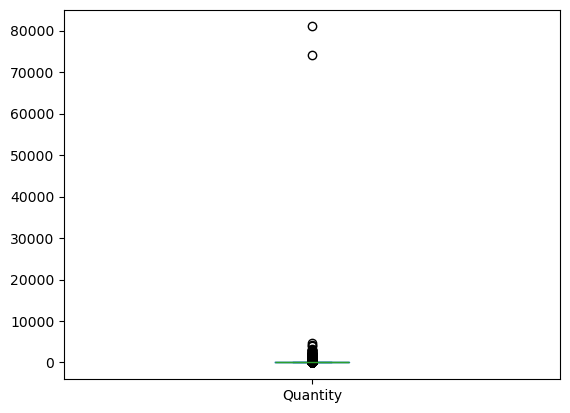

In [98]:
sales_clean_df['Quantity'].plot.box()

<Axes: >

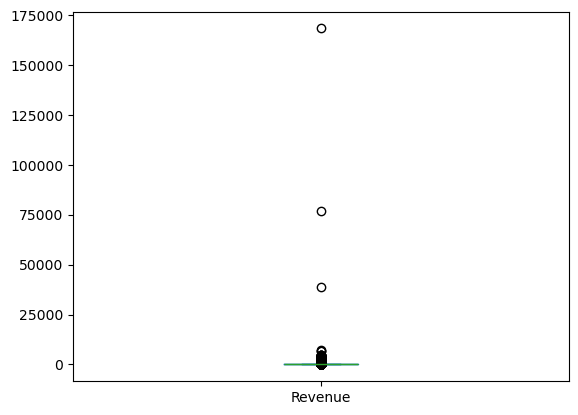

In [99]:
sales_clean_df['Revenue'].plot.box()

<Axes: >

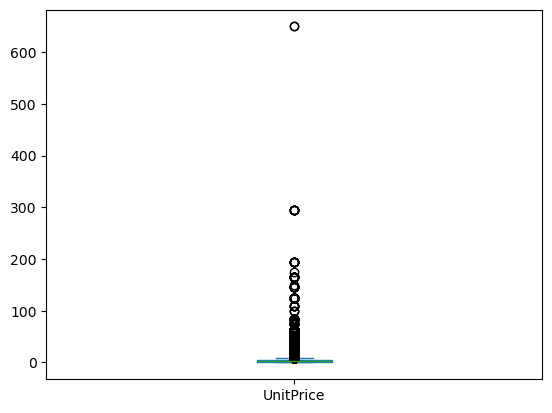

In [100]:
sales_clean_df['UnitPrice'].plot.box()

In [ ]:
for col in ['UnitPrice', 'Revenue']:
    Q1 = sales_clean_df[col].quantile(0.25)
    Q2 = sales_clean_df[col].quantile(0.50)
    Q3 = sales_clean_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"\n{col}")
    print("Q1:", Q1)
    print("Q2 (Median):", Q2)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower)
    print("Upper Bound:", upper)

In [101]:
quantity_outliers = sales_clean_df[
    sales_clean_df['Quantity'] > 26
]

unitprice_outliers = sales_clean_df[
    sales_clean_df['UnitPrice'] > 8.45
]

revenue_outliers = sales_clean_df[
    sales_clean_df['Revenue'] > 38.025
]

print("Quantity outliers:", len(quantity_outliers))
print("UnitPrice outliers:", len(unitprice_outliers))
print("Revenue outliers:", len(revenue_outliers))

Quantity outliers: 27115
UnitPrice outliers: 36096
Revenue outliers: 41694


In [102]:
sales_clean_df.nlargest(20, 'Quantity')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'Revenue', 'CustomerID']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00,12901.0
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00,13135.0
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92,18087.0
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16,14609.0
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00,16308.0
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40,16754.0


In [103]:
high_qty = sales_clean_df[sales_clean_df['Quantity'] > 26]

high_qty.groupby(
    ['StockCode', 'Description']
).agg(
    Transactions=('InvoiceNo', 'count'),
    Total_Quantity=('Quantity', 'sum'),
    Max_Quantity=('Quantity', 'max')
).sort_values(
    'Total_Quantity',
    ascending=False
).head(20)

,,Transactions,Total_Quantity,Max_Quantity
StockCode,Description,,,
23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995,80995
23166,MEDIUM CERAMIC TOP STORAGE JAR,31,76471,74215
84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,464,54699,4800
85099B,JUMBO BAG RED RETROSPOT,293,34403,1200
22197,POPCORN HOLDER,196,30351,1992
22492,MINI PAINT SET VINTAGE,324,26493,1394
85123A,WHITE HANGING HEART T-LIGHT HOLDER,351,26010,1930
23084,RABBIT NIGHT LIGHT,185,23592,2400
17003,BROCADE RING PURSE,165,22669,720


In [104]:
sales_clean_df[
    sales_clean_df['StockCode'] == '23843'
][[
    'InvoiceNo',
    'InvoiceDate',
    'Description',
    'Quantity',
    'UnitPrice',
    'Revenue',
    'CustomerID'
]].sort_values('Quantity', ascending=False)

,InvoiceNo,InvoiceDate,Description,Quantity,UnitPrice,Revenue,CustomerID
540421,581483,2011-12-09 09:15:00,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.6,16446.0


In [105]:
sales_clean_df.nlargest(20, 'UnitPrice')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'Revenue', 'CustomerID']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.5,38970.0,15098.0
222682,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,649.5,649.5,15098.0
4989,536835,22655,VINTAGE RED KITCHEN CABINET,1,295.0,295.0,13145.0
32484,539080,22655,VINTAGE RED KITCHEN CABINET,1,295.0,295.0,16607.0
51636,540647,22655,VINTAGE RED KITCHEN CABINET,1,295.0,295.0,17406.0
82768,543253,22655,VINTAGE RED KITCHEN CABINET,1,295.0,295.0,14842.0
118769,546480,22656,VINTAGE BLUE KITCHEN CABINET,1,295.0,295.0,13452.0
133994,547814,22656,VINTAGE BLUE KITCHEN CABINET,1,295.0,295.0,13452.0
171178,551393,22656,VINTAGE BLUE KITCHEN CABINET,1,295.0,295.0,14973.0
205759,554836,22655,VINTAGE RED KITCHEN CABINET,1,295.0,295.0,13015.0


In [106]:
df[df['InvoiceNo'].astype(str).isin(['556444', '556446'])]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.5,15098.0,United Kingdom
222682,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2011-06-10 15:33:00,649.5,15098.0,United Kingdom


In [107]:
sales_clean_df.nlargest(20, 'Revenue')[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'Revenue', 'CustomerID']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,38970.00,15098.0
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,7144.72,17450.0
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,4992.00,14646.0
52709,540815,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.55,4921.50,15749.0
467804,576365,22086,PAPER CHAIN KIT 50'S CHRISTMAS,688,6.95,4781.60,NaN
160542,550461,85123A,WHITE HANGING HEART T-LIGHT HOLDER,1930,2.40,4632.00,15749.0


In [108]:
sales_clean_df


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Is_Outlier
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,False
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,False
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,False
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,False
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,False
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,False
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,False


In [109]:
sales_df['Quantity'].describe(percentiles=[.90, .95, .99, .995, .999])

count    529083.000000
mean         10.670229
std         157.099233
min           1.000000
50%           3.000000
90%          24.000000
95%          30.000000
99%         100.000000
99.5%       168.000000
99.9%       480.000000
max       80995.000000
Name: Quantity, dtype: float64

In [110]:
sales_df.sort_values('Quantity', ascending=False)[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'Revenue', 'CustomerID']
].head(30)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446.0
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346.0
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00,0.00,13256.0
74614,542504,37413,NaN,5568,0.00,0.00,NaN
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00,12901.0
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00,13135.0
220843,556231,85123A,?,4000,0.00,0.00,NaN
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92,18087.0
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16,14609.0
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749.0


In [115]:
sales_df[sales_df['InvoiceNo'] == 581483]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue


In [112]:
sales_df[sales_df['InvoiceNo'] == 541431]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue


In [113]:
sales_df[sales_df['CustomerID'] == 16446].sort_values(
    'Quantity', ascending=False
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.60
194354,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446.0,United Kingdom,1.65
194355,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446.0,United Kingdom,1.25


In [114]:
sales_df[sales_df['CustomerID'] == 12346].sort_values(
    'Quantity', ascending=False
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6


In [116]:
sales_df[sales_df['InvoiceNo'] == 541431]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue


In [117]:
quantity_outliers = sales_df[
    sales_df['Quantity'] > 10000
]

quantity_outliers[
    ['InvoiceNo', 'StockCode', 'Description',
     'Quantity', 'UnitPrice', 'Revenue', 'CustomerID']
]

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.6,12346.0
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00,0.0,13256.0
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.6,16446.0


In [119]:
sales_df[sales_df['StockCode'] == '23843'].sort_values(
    'Quantity', ascending=False
)[['InvoiceNo', 'StockCode', 'Description',
   'Quantity', 'UnitPrice', 'CustomerID', 'Revenue']].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,168469.6


In [120]:
sales_df[sales_df['StockCode'] == '23166'].sort_values(
    'Quantity', ascending=False
)[['InvoiceNo', 'StockCode', 'Description',
   'Quantity', 'UnitPrice', 'CustomerID', 'Revenue']].head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Revenue
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,77183.60
285367,561901,23166,MEDIUM CERAMIC TOP STORAGE JAR,288,1.25,14156.0,360.00
194462,553607,23166,MEDIUM CERAMIC TOP STORAGE JAR,240,1.04,16684.0,249.60
276513,561051,23166,MEDIUM CERAMIC TOP STORAGE JAR,144,1.04,16684.0,149.76
186770,552882,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,14646.0,99.84
485775,577669,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,15567.0,99.84
228160,556917,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,12415.0,99.84
201570,554307,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,12989.0,99.84
304929,563614,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,12415.0,99.84
526381,580665,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,16684.0,99.84


In [121]:
sales_df[sales_df['CustomerID'] == 12346]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6


In [122]:
df[df['InvoiceNo'] == 541431]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [123]:
df[df['InvoiceNo'].astype(str).str.contains('541431', na=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom


In [124]:
sales_df[sales_df['InvoiceNo'].astype(str).str.contains('541431', na=False)]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6


In [139]:

sales_df['Description'] = sales_df['Description'].fillna('Unknown_Item')

In [140]:
sales_df[['CustomerID', 'Description']].isna().sum()

CustomerID     0
Description    0
dtype: int64

In [141]:
sales_df


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [143]:
sales_df['CustomerID'].value_counts().head()

CustomerID
Unknown    132568
17841        7838
14911        5675
14096        5095
12748        4580
Name: count, dtype: Int64

In [144]:
sales_df['Description'].value_counts().head()

Description
WHITE HANGING HEART T-LIGHT HOLDER    2327
JUMBO BAG RED RETROSPOT               2115
REGENCY CAKESTAND 3 TIER              2019
PARTY BUNTING                         1707
LUNCH BAG RED RETROSPOT               1594
Name: count, dtype: int64

In [147]:
sales_df['CustomerID'] = sales_df['CustomerID'].astype('string')

In [148]:
sales_df['CustomerID'] = sales_df['CustomerID'].fillna(0)

In [150]:
print(sales_df['CustomerID'].dtype)

string


In [151]:
print("Unknown CustomerID:", (sales_df['CustomerID'] == 'Unknown').sum())
print("Unknown Description:", (sales_df['Description'] == 'Unknown_Item').sum())

Unknown CustomerID: 132568
Unknown Description: 587


In [152]:
print(sales_df[['CustomerID', 'Description']].isna().sum())

CustomerID     0
Description    0
dtype: int64


In [153]:
sales_df[['CustomerID', 'Description']].isna().sum()

CustomerID     0
Description    0
dtype: int64

In [154]:
sales_df[sales_df['UnitPrice'] == 0].shape

(1166, 9)

In [155]:
sales_df[sales_df['UnitPrice'] == 0].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
622,536414,22139,Unknown_Item,56,2010-12-01 11:52:00,0.0,Unknown,United Kingdom,0.0
1970,536545,21134,Unknown_Item,1,2010-12-01 14:32:00,0.0,Unknown,United Kingdom,0.0
1971,536546,22145,Unknown_Item,1,2010-12-01 14:33:00,0.0,Unknown,United Kingdom,0.0
1972,536547,37509,Unknown_Item,1,2010-12-01 14:33:00,0.0,Unknown,United Kingdom,0.0
1987,536549,85226A,Unknown_Item,1,2010-12-01 14:34:00,0.0,Unknown,United Kingdom,0.0
1988,536550,85044,Unknown_Item,1,2010-12-01 14:34:00,0.0,Unknown,United Kingdom,0.0
2024,536552,20950,Unknown_Item,1,2010-12-01 14:34:00,0.0,Unknown,United Kingdom,0.0
2025,536553,37461,Unknown_Item,3,2010-12-01 14:35:00,0.0,Unknown,United Kingdom,0.0
2026,536554,84670,Unknown_Item,23,2010-12-01 14:35:00,0.0,Unknown,United Kingdom,0.0
4348,536765,84952C,Unknown_Item,19,2010-12-02 14:43:00,0.0,Unknown,United Kingdom,0.0


In [156]:
sales_df[sales_df['UnitPrice'] == 0]['Description'].value_counts().head(20)

Description
Unknown_Item                       587
check                               39
found                               25
adjustment                          14
FRENCH BLUE METAL DOOR SIGN 1        9
Found                                8
FRENCH BLUE METAL DOOR SIGN 8        8
amazon                               8
RECIPE BOX PANTRY YELLOW DESIGN      7
FRENCH BLUE METAL DOOR SIGN 4        7
FRENCH BLUE METAL DOOR SIGN No       7
Amazon                               7
OWL DOORSTOP                         7
FRENCH BLUE METAL DOOR SIGN 3        7
FRENCH BLUE METAL DOOR SIGN 5        6
FRENCH BLUE METAL DOOR SIGN 6        6
?                                    6
RED KITCHEN SCALES                   6
FRENCH BLUE METAL DOOR SIGN 7        6
MINT KITCHEN SCALES                  6
Name: count, dtype: int64

In [157]:
sales_df[sales_df['UnitPrice'] == 0]['Revenue'].sum()

np.float64(0.0)

In [161]:
sales_df.loc[sales_df['UnitPrice'] == 0, 'Revenue'].sum()

np.float64(0.0)

In [159]:
(sales_df['UnitPrice'] == 0).sum()

np.int64(1166)

In [160]:
sales_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [162]:
sales_df[sales_df['StockCode'].isin(['POST', 'DOT', 'M', 'D', 'AMAZONFEE'])][
    ['StockCode', 'Description', 'Quantity', 'UnitPrice', 'Revenue', 'CustomerID', 'Country']
].head(30)

,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,Country


In [163]:
sales_df['StockCode'].isin(['POST', 'DOT', 'M', 'D', 'AMAZONFEE']).sum()

np.int64(0)

In [164]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 529083 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    529083 non-null  object        
 1   StockCode    529083 non-null  object        
 2   Description  529083 non-null  object        
 3   Quantity     529083 non-null  int64         
 4   InvoiceDate  529083 non-null  datetime64[ns]
 5   UnitPrice    529083 non-null  float64       
 6   CustomerID   529083 non-null  string        
 7   Country      529083 non-null  object        
 8   Revenue      529083 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(4), string(1)
memory usage: 40.4+ MB


In [165]:
sales_df.isna().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

In [166]:
sales_df[['Quantity', 'UnitPrice', 'Revenue']].describe()

,Quantity,UnitPrice,Revenue
count,529083.000000,529083.000000,529083.000000
mean,10.670229,3.271957,19.428029
std,157.099233,4.446968,268.271196
min,1.000000,0.000000,0.000000
25%,1.000000,1.250000,3.750000
50%,3.000000,2.080000,9.900000
75%,11.000000,4.130000,17.400000
max,80995.000000,649.500000,168469.600000


In [167]:
sales_df.to_csv("OnlineRetail_Cleaned_Sales.csv", index=False)

In [170]:
sales_df.to_excel("OnlineRetail_Cleaned_Sales.xlsx", index=False)

In [171]:
import os

print(os.path.abspath("OnlineRetail_Cleaned_Sales.csv"))
print(os.path.abspath("OnlineRetail_Cleaned_Sales.xlsx"))

C:\Users\adity\OnlineRetail_Cleaned_Sales.csv
C:\Users\adity\OnlineRetail_Cleaned_Sales.xlsx
